# Identitas Diri
- Nama: Muhammad Abiya Makruf
- Username: Abiyamf

## Import library

In [34]:
import random

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf


In [35]:
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)

## Data loading & Eksplorasi Data

In [36]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
raw_df = pd.read_csv(csv_url)

In [37]:
raw_df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [38]:
raw_df.tail()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
53145,2023-10-19 19:00:00,28750.75,2.984059e+07,53.630054,109.926882,129.065981,7.459700
53146,2023-10-19 20:00:00,28715.38,4.997623e+07,53.531282,111.721905,129.268969,7.118597
53147,2023-10-19 21:00:00,28604.09,3.205666e+07,53.221944,113.055031,129.287930,6.210037
53148,2023-10-19 22:00:00,28649.65,2.200420e+07,53.332673,114.513131,129.219782,6.515616
53149,2023-10-19 23:00:00,28713.71,1.758298e+07,53.487941,116.161806,129.096002,6.963753


In [39]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


In [40]:
TARGET = 'Close'
CANDIDATE_FEATURES = [column for column in raw_df.columns if column not in ['Date', TARGET]]

print('Target:', TARGET)
print('Kandidat fitur non-target:', CANDIDATE_FEATURES)


Target: Close
Kandidat fitur non-target: ['Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']


## Data preparation

In [41]:
df = raw_df.copy()

In [42]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date').drop_duplicates(subset=['Date']).reset_index(drop=True)

In [43]:
ROLLING_WINDOW = 24

def add_rolling_features(df, target_column=TARGET, rolling_window=ROLLING_WINDOW):
    enriched = df.copy()
    enriched['close_roll_mean_24'] = enriched[target_column].rolling(rolling_window, min_periods=rolling_window).mean()
    enriched = enriched.dropna().reset_index(drop=True)
    return enriched

df = add_rolling_features(df)


Jumlah data split: 11650 1664 3329
Fitur non-target dengan korelasi tertinggi pada train: ['ATR', 'RSI', 'Volume USDT']
Fitur final yang digunakan: ['Close', 'ATR', 'RSI', 'Volume USDT', 'close_roll_mean_24']


,abs_corr_to_close_train
ATR,0.813546
RSI,0.397030
Volume USDT,0.214357
KAMAO,0.121041
MACD_Hist,0.004598


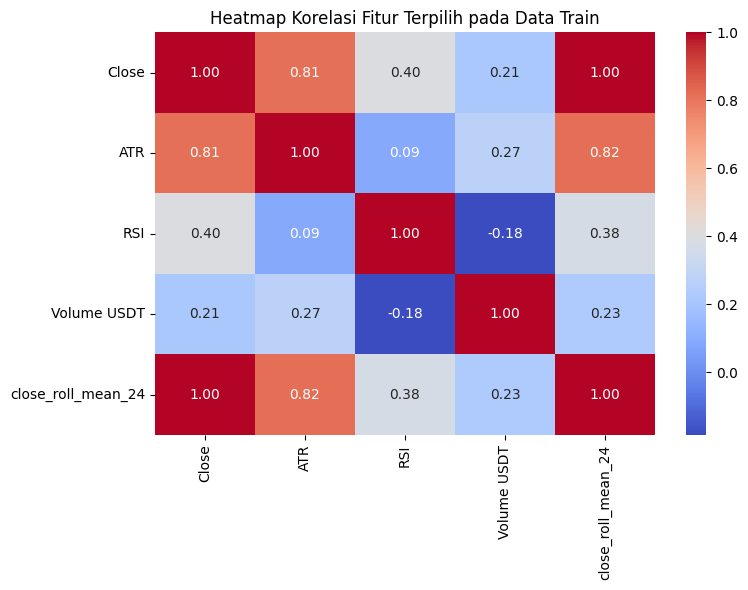

In [44]:
# Split data dilakukan sebelum pemilihan fitur final agar korelasi hanya dihitung dari data train.
TRAIN_RATIO = 0.70
VAL_RATIO = 0.10
TEST_RATIO = 0.20

train_df = df.iloc[:int(len(df) * TRAIN_RATIO)].reset_index(drop=True)
val_df = df.iloc[int(len(df) * TRAIN_RATIO):int(len(df) * (TRAIN_RATIO + VAL_RATIO))].reset_index(drop=True)
test_df = df.iloc[int(len(df) * (TRAIN_RATIO + VAL_RATIO)):].reset_index(drop=True)

train_correlation_to_target = (
    train_df[[TARGET, *CANDIDATE_FEATURES]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)
TOP_CORRELATED_FEATURES = train_correlation_to_target.head(3).index.tolist()
FEATURE = [TARGET, *TOP_CORRELATED_FEATURES, 'close_roll_mean_24']

print('Jumlah data split:', len(train_df), len(val_df), len(test_df))
print('Fitur non-target dengan korelasi tertinggi pada train:', TOP_CORRELATED_FEATURES)
print('Fitur final yang digunakan:', FEATURE)
display(train_correlation_to_target.to_frame(name='abs_corr_to_close_train'))

plt.figure(figsize=(8, 6))
sns.heatmap(train_df[FEATURE].corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Terpilih pada Data Train')
plt.tight_layout()
plt.show()


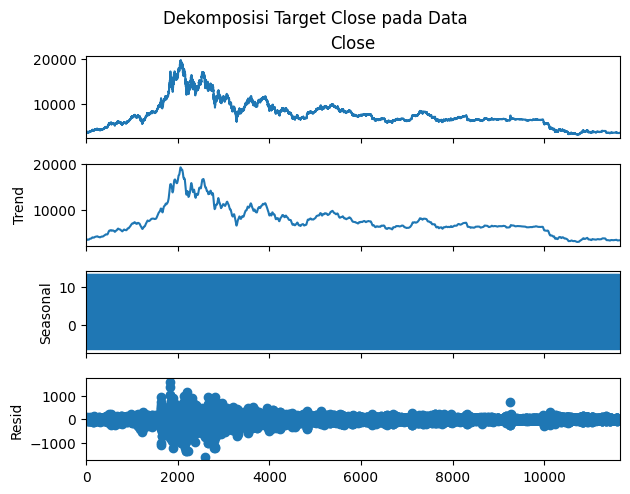

In [45]:
# Analisis dekomposisi untuk melihat komponen tren, musiman, dan residu
decomposition = seasonal_decompose(train_df[TARGET], model='additive', period=24)
decomposition.plot()
plt.suptitle('Dekomposisi Target Close pada Data', y=1.02)
plt.show()

,lag,acf,pacf,score,significant
0,24,0.982794,-0.027819,0.982794,True
1,48,0.966817,0.001694,0.966817,True
2,72,0.950498,-0.019747,0.950498,True
3,96,0.934422,-0.007910,0.934422,True
4,168,0.886990,0.018820,0.886990,True


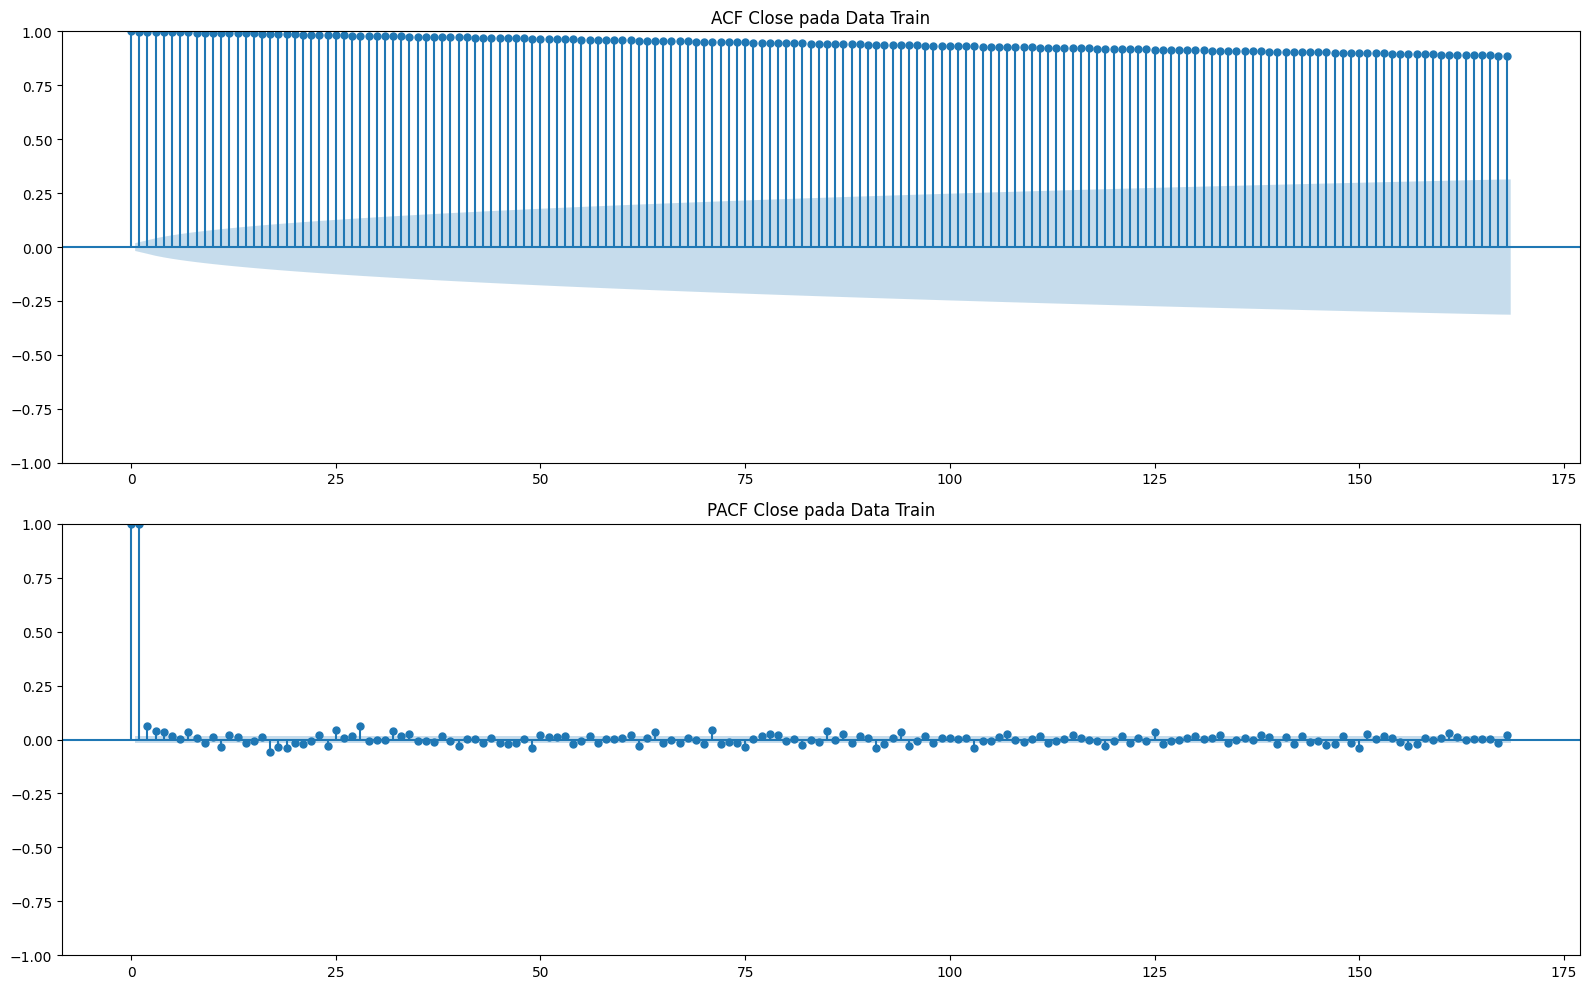

Significance threshold: 0.01816
Selected window size from ACF/PACF analysis: 48


In [46]:
WINDOW_CANDIDATES = (24, 48, 72, 96, 168)
def select_window_size_from_lag_analysis(series, candidate_windows=WINDOW_CANDIDATES):
    max_lag = max(candidate_windows)
    acf_values = acf(series, nlags=max_lag, fft=True)
    pacf_values = pacf(series, nlags=max_lag, method='ywm')
    significance_threshold = 1.96 / np.sqrt(len(series))

    lag_rows = []
    selected_window = 24
    for lag in candidate_windows:
        acf_at_lag = float(acf_values[lag])
        pacf_at_lag = float(pacf_values[lag])
        score = max(abs(acf_at_lag), abs(pacf_at_lag))
        lag_rows.append({
            'lag': lag,
            'acf': acf_at_lag,
            'pacf': pacf_at_lag,
            'score': score,
            'significant': score >= significance_threshold,
        })
        if score >= significance_threshold and selected_window == 24:
            selected_window = lag

    lag_summary = pd.DataFrame(lag_rows)
    return selected_window, significance_threshold, lag_summary
selected_window_size, significance_threshold, lag_summary_df = select_window_size_from_lag_analysis(train_df[TARGET])
display(lag_summary_df)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
plot_acf(train_df[TARGET], lags=max(WINDOW_CANDIDATES), ax=axes[0])
plot_pacf(train_df[TARGET], lags=max(WINDOW_CANDIDATES), ax=axes[1], method='ywm')
axes[0].set_title('ACF Close pada Data Train')
axes[1].set_title('PACF Close pada Data Train')
plt.tight_layout()
plt.show()

print(f'Significance threshold: {significance_threshold:.5f}')
print(f'Selected window size from ACF/PACF analysis: {selected_window_size}')


In [47]:
# Scale data
scalers = {}
for col in FEATURE :
    scaler = MinMaxScaler()
    scaler.fit(train_df[[col]])
    scalers[col] = scaler

for col in FEATURE :
    train_df[col] = scalers[col].transform(train_df[[col]])
    val_df[col] = scalers[col].transform(val_df[[col]])
    test_df[col] = scalers[col].transform(test_df[[col]])


In [48]:
train_df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,close_roll_mean_24
0,2017-09-22 08:00:00,0.028762,0.000748,0.467362,-49.453354,0.141062,0.015093,0.031060
1,2017-09-22 09:00:00,0.026298,0.000816,0.461314,-49.745629,0.140841,-0.453320,0.030401
2,2017-09-22 10:00:00,0.024236,0.001163,0.456266,-50.150669,0.140576,-0.843745,0.029623
3,2017-09-22 11:00:00,0.022248,0.001473,0.451406,-50.661754,0.140531,-1.217532,0.028777
4,2017-09-22 12:00:00,0.025401,0.000974,0.459685,-50.963345,0.140488,-0.610674,0.028085


In [49]:
WINDOW_SIZE = selected_window_size
HORIZON = 24

def make_supervised_windows(df, feature_columns, target_column, window_size, horizon=HORIZON):
    feature_values = df[feature_columns].to_numpy(dtype=np.float32)
    target_values = df[target_column].to_numpy(dtype=np.float32)
    timestamps = df['Date'].to_numpy()
    target_index = feature_columns.index(target_column)

    X, y, y_timestamps, last_close_values = [], [], [], []
    for end_idx in range(window_size, len(df) - horizon + 1):
        start_idx = end_idx - window_size
        target_slice = slice(end_idx, end_idx + horizon)
        X.append(feature_values[start_idx:end_idx])
        y.append(target_values[target_slice].reshape(horizon, 1))
        y_timestamps.append(timestamps[target_slice])
        last_close_values.append(feature_values[end_idx - 1, target_index])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    y_timestamps = np.asarray(y_timestamps)
    last_close_values = np.asarray(last_close_values, dtype=np.float32)
    return X, y, y_timestamps, last_close_values

X_train, y_train, train_timestamps, train_last_close = make_supervised_windows(train_df, FEATURE, TARGET, WINDOW_SIZE)
X_val, y_val, val_timestamps, val_last_close = make_supervised_windows(val_df, FEATURE, TARGET, WINDOW_SIZE)
X_test, y_test, test_timestamps, test_last_close = make_supervised_windows(test_df, FEATURE, TARGET, WINDOW_SIZE)


In [50]:
def build_decoder_inputs(y_true, last_close_values):
    decoder_inputs = np.zeros_like(y_true, dtype=np.float32)
    decoder_inputs[:, 0, 0] = last_close_values
    decoder_inputs[:, 1:, 0] = y_true[:, :-1, 0]
    return decoder_inputs

train_decoder_inputs = build_decoder_inputs(y_train, train_last_close)
val_decoder_inputs = build_decoder_inputs(y_val, val_last_close)
test_decoder_inputs = build_decoder_inputs(y_test, test_last_close)

In [51]:
BATCH_SIZE = 144
EPOCHS = 40
CUSTOM_BASELINE_EPOCHS = 10
CUSTOM_SEQ2SEQ_EPOCHS = 50

def make_tf_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(X), 4096), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_tf_dataset(X_train, y_train, shuffle=True)
val_ds = make_tf_dataset(X_val, y_val, shuffle=False)
test_ds = make_tf_dataset(X_test, y_test, shuffle=False)


In [52]:
def make_seq2seq_tf_dataset(encoder_inputs, decoder_inputs, targets, batch_size=BATCH_SIZE, shuffle=False):
    inputs = {
        'encoder_inputs': encoder_inputs.astype(np.float32),
        'decoder_inputs': decoder_inputs.astype(np.float32),
    }
    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(encoder_inputs), 4096), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
    return dataset
train_seq2seq_ds = make_seq2seq_tf_dataset(X_train, train_decoder_inputs, y_train, shuffle=True)
val_seq2seq_ds = make_seq2seq_tf_dataset(X_val, val_decoder_inputs, y_val, shuffle=False)
test_seq2seq_ds = make_seq2seq_tf_dataset(X_test, test_decoder_inputs, y_test, shuffle=False)


## Custom layer

In [53]:
@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.use_bias = use_bias

    def build(self, input_shape):
        last_dim = int(input_shape[-1])
        self.kernel = self.add_weight(
            name='kernel',
            shape=(last_dim, self.units),
            initializer='glorot_uniform',
            trainable=True,
        )
        self.bias = None
        if self.use_bias:
            self.bias = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer='zeros',
                trainable=True,
            )
        super().build(input_shape)

    def call(self, inputs):
        outputs = tf.linalg.matmul(inputs, self.kernel)
        if self.use_bias:
            outputs = outputs + self.bias
        if self.activation is not None:
            outputs = self.activation(outputs)
        return outputs

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
            'use_bias': self.use_bias,
        })
        return config

@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomLayerNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        feature_dim = int(input_shape[-1])
        self.gamma = self.add_weight(
            name='gamma',
            shape=(feature_dim,),
            initializer='ones',
            trainable=True,
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(feature_dim,),
            initializer='zeros',
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return normalized * self.gamma + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config

@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        if key_dim <= 0:
            raise ValueError('key_dim must be positive')
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout = dropout
        self.dropout_layer = tf.keras.layers.Dropout(dropout)

    def build(self, input_shape):
        is_multi_input = (
            isinstance(input_shape, (list, tuple))
            and len(input_shape) > 0
            and isinstance(input_shape[0], (list, tuple, tf.TensorShape))
        )
        if is_multi_input:
            query_shape = tf.TensorShape(input_shape[0])
            value_shape = tf.TensorShape(input_shape[1] if len(input_shape) > 1 else input_shape[0])
        else:
            query_shape = tf.TensorShape(input_shape)
            value_shape = tf.TensorShape(input_shape)
        if query_shape.rank is None or value_shape.rank is None or query_shape[-1] is None or value_shape[-1] is None:
            raise ValueError(f'Unable to infer attention dimensions from input_shape={input_shape}')

        query_dim = int(query_shape[-1])
        projection_dim = self.num_heads * self.key_dim
        self.query_dense = CustomDense(projection_dim, name='query_dense')
        self.key_dense = CustomDense(projection_dim, name='key_dense')
        self.value_dense = CustomDense(projection_dim, name='value_dense')
        self.output_dense = CustomDense(query_dim, name='output_dense')

        self.query_dense.build(query_shape)
        self.key_dense.build(value_shape)
        self.value_dense.build(value_shape)
        self.output_dense.build(tf.TensorShape([None, None, projection_dim]))
        super().build(input_shape)

    def _split_heads(self, x):
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        x = tf.reshape(x, [batch_size, seq_len, self.num_heads, self.key_dim])
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def _combine_heads(self, x):
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        batch_size = tf.shape(x)[0]
        seq_len = tf.shape(x)[1]
        return tf.reshape(x, [batch_size, seq_len, self.num_heads * self.key_dim])

    def call(self, query, value=None, key=None, training=False):
        if value is None:
            value = query
        if key is None:
            key = value

        query_proj = self._split_heads(self.query_dense(query))
        key_proj = self._split_heads(self.key_dense(key))
        value_proj = self._split_heads(self.value_dense(value))

        attention_logits = tf.matmul(query_proj, key_proj, transpose_b=True)
        attention_logits = attention_logits / tf.math.sqrt(tf.cast(self.key_dim, tf.float32))
        attention_weights = tf.nn.softmax(attention_logits, axis=-1)
        attention_weights = self.dropout_layer(attention_weights, training=training)

        attention_output = tf.matmul(attention_weights, value_proj)
        attention_output = self._combine_heads(attention_output)
        return self.output_dense(attention_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout': self.dropout,
        })
        return config


## Building model

In [54]:
MODEL_UNITS = 64
NUM_HEADS = 2
KEY_DIM = 16
DROPOUT_RATE = 0.20

### Baseline LSTM dengan custom dense dan MultiHeadAttention

In [55]:
# Baseline LSTM diubah agar return_sequences=True lalu ditambah CustomMultiHeadAttention.
def build_attention_baseline_model(window_size, num_features, horizon, lstm_units=MODEL_UNITS, num_heads=NUM_HEADS, key_dim=KEY_DIM, dropout=DROPOUT_RATE):
    encoder_inputs = tf.keras.Input(shape=(window_size, num_features), name='encoder_inputs')
    x = tf.keras.layers.LSTM(lstm_units, return_sequences=True, name='baseline_encoder')(encoder_inputs)

    attention_output = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name='baseline_self_attention')(x, x, x)

    x = CustomLayerNormalization(name='baseline_attention_norm')(x + attention_output)
    x = tf.keras.layers.LSTM(lstm_units // 2, name='baseline_projection')(x)
    x = CustomDense(64, activation='relu', name='baseline_dense_head')(x)
    x = CustomDense(horizon, name='baseline_output_dense')(x)
    outputs = tf.keras.layers.Reshape((horizon, 1), name='baseline_outputs')(x)
    return tf.keras.Model(encoder_inputs, outputs, name='baseline_lstm_attention_model')

### Seq2Seq

In [56]:
# Seq2Seq Teacher Forcing dengan Functional API.
def build_functional_seq2seq(window_size, num_features, horizon, lstm_units=MODEL_UNITS):
    encoder_inputs = tf.keras.Input(shape=(window_size, num_features), name='encoder_inputs')
    decoder_inputs = tf.keras.Input(shape=(horizon, 1), name='decoder_inputs')

    encoder_outputs, state_h, state_c = tf.keras.layers.LSTM(
        lstm_units,
        return_sequences=True,
        return_state=True,
        name='encoder_lstm',
    )(encoder_inputs)

    decoder_outputs = tf.keras.layers.LSTM(
        lstm_units,
        return_sequences=True,
        name='decoder_lstm',
    )(decoder_inputs, initial_state=[state_h, state_c])

    hidden = CustomDense(lstm_units // 2, activation='relu', name='functional_seq2seq_hidden')(decoder_outputs)
    outputs = CustomDense(1, name='functional_seq2seq_output')(hidden)
    return tf.keras.Model([encoder_inputs, decoder_inputs], outputs, name='functional_seq2seq_teacher_forcing')

In [57]:
@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class SubclassedSeq2Seq(tf.keras.Model):
    def __init__(self, horizon, lstm_units=MODEL_UNITS, num_heads=NUM_HEADS, key_dim=KEY_DIM, dropout=DROPOUT_RATE, **kwargs):
        super().__init__(**kwargs)
        self.horizon = horizon
        self.lstm_units = lstm_units
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.dropout_rate = dropout

        self.encoder = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
        self.decoder = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True, name='decoder_lstm')
        self.cross_attention = CustomMultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=dropout, name='cross_attention')
        self.norm = CustomLayerNormalization(name='cross_attention_norm')
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.hidden_dense = CustomDense(lstm_units // 2, activation='relu', name='seq2seq_hidden_dense')
        self.output_dense = CustomDense(1, name='seq2seq_output_dense')

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs
        encoder_outputs, state_h, state_c = self.encoder(encoder_inputs, training=training)
        decoder_outputs, _, _ = self.decoder(decoder_inputs, initial_state=[state_h, state_c], training=training)

        attended = self.cross_attention(decoder_outputs, encoder_outputs, encoder_outputs, training=training)
        x = self.norm(decoder_outputs + attended)
        x = self.dropout(x, training=training)
        x = self.hidden_dense(x)
        return self.output_dense(x)

    def encode(self, encoder_inputs, training=False):
        return self.encoder(encoder_inputs, training=training)

    def decode_step(self, decoder_inputs, encoder_outputs, states, training=False):
        decoder_outputs, state_h, state_c = self.decoder(decoder_inputs, initial_state=states, training=training)
        attended = self.cross_attention(decoder_outputs, encoder_outputs, encoder_outputs, training=training)
        x = self.norm(decoder_outputs + attended)
        x = self.dropout(x, training=training)
        x = self.hidden_dense(x)
        return self.output_dense(x), [state_h, state_c]

    def get_config(self):
        config = super().get_config()
        config.update({
            'horizon': self.horizon,
            'lstm_units': self.lstm_units,
            'num_heads': self.num_heads,
            'key_dim': self.key_dim,
            'dropout': self.dropout_rate,
        })
        return config

functional_seq2seq_model = build_functional_seq2seq(WINDOW_SIZE, len(FEATURE), HORIZON)
baseline_attention_model = build_attention_baseline_model(WINDOW_SIZE, len(FEATURE), HORIZON)
subclassed_seq2seq_model = SubclassedSeq2Seq(horizon=HORIZON, name='subclassed_seq2seq_model')


Epoch 1/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.3138 - mae: 0.3138 - val_loss: 0.0615 - val_mae: 0.0615
Epoch 2/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.1286 - mae: 0.1286 - val_loss: 0.0405 - val_mae: 0.0405
Epoch 3/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0904 - mae: 0.0904 - val_loss: 0.0100 - val_mae: 0.0100
Epoch 4/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0695 - mae: 0.0695 - val_loss: 0.0072 - val_mae: 0.0072
Epoch 5/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0545 - mae: 0.0545 - val_loss: 0.0066 - val_mae: 0.0066
Epoch 6/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0431 - mae: 0.0431 - val_loss: 0.0078 - val_mae: 0.0078
Epoch 7/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0343 - mae: 0.0343 - val_loss: 0.0066 - val_mae: 0.0066
Epoch 8/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0290 - mae: 0.0290 - val_loss: 0.0081 - val_mae: 0.0081
Epoch 9/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.025

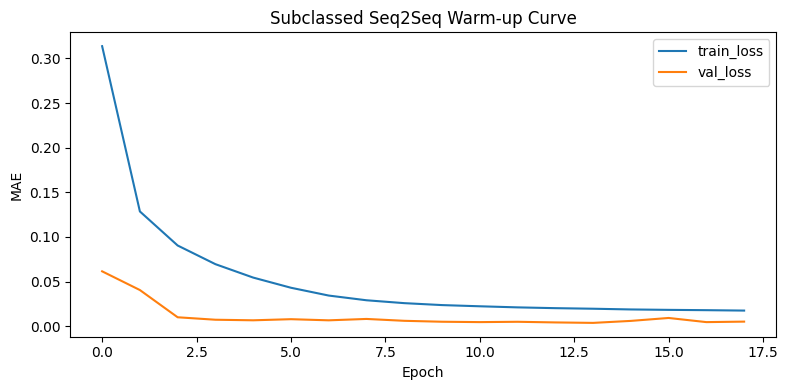

In [58]:
def make_seq2seq_tuple_dataset(encoder_inputs, decoder_inputs, targets, batch_size=BATCH_SIZE, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(((encoder_inputs.astype(np.float32), decoder_inputs.astype(np.float32)), targets.astype(np.float32)))
    if shuffle:
        dataset = dataset.shuffle(min(len(encoder_inputs), 4096), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
    return dataset

train_seq2seq_tuple_ds = make_seq2seq_tuple_dataset(X_train, train_decoder_inputs, y_train, shuffle=True)
val_seq2seq_tuple_ds = make_seq2seq_tuple_dataset(X_val, val_decoder_inputs, y_val, shuffle=False)
test_seq2seq_tuple_ds = make_seq2seq_tuple_dataset(X_test, test_decoder_inputs, y_test, shuffle=False)

subclassed_seq2seq_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss='mae',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
)

warmup_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience=4, restore_best_weights=True, min_delta=1e-4)
]

history_subclassed_seq2seq = subclassed_seq2seq_model.fit(
    train_seq2seq_tuple_ds,
    validation_data=val_seq2seq_tuple_ds,
    epochs=EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

plt.figure(figsize=(8, 4))
plt.plot(history_subclassed_seq2seq.history['loss'], label='train_loss')
plt.plot(history_subclassed_seq2seq.history['val_loss'], label='val_loss')
plt.title('Subclassed Seq2Seq Warm-up Curve')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()


### Tambahan custom layer

In [59]:
def custom_mae(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.abs(y_true - y_pred))


def weighted_horizon_mae(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    horizon = tf.shape(y_true)[1]
    weights = tf.linspace(1.0, 1.15, horizon)
    weights = tf.reshape(weights, (1, horizon, 1))
    abs_error = tf.abs(y_true - y_pred)
    weighted_error = abs_error * weights
    return 0.92 * tf.reduce_mean(abs_error) + 0.08 * tf.reduce_mean(weighted_error)


def get_optimizer_lr(optimizer):
    learning_rate = optimizer.learning_rate
    if isinstance(learning_rate, tf.keras.optimizers.schedules.LearningRateSchedule):
        current_lr = learning_rate(optimizer.iterations)
        return float(tf.keras.backend.get_value(current_lr))
    if hasattr(learning_rate, 'numpy'):
        return float(learning_rate.numpy())
    return float(learning_rate)


def set_optimizer_lr(optimizer, new_lr):
    learning_rate = optimizer.learning_rate
    if hasattr(learning_rate, 'assign'):
        learning_rate.assign(new_lr)
    else:
        optimizer.learning_rate = new_lr


@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomEarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best = np.inf
        self.wait = 0
        self.best_weights = None
        self.stop_training = False

    def on_train_begin(self, model):
        self.best = np.inf
        self.wait = 0
        self.best_weights = model.get_weights() if self.restore_best_weights else None
        self.stop_training = False

    def on_epoch_end(self, model, optimizer, current, epoch):
        if current < (self.best - self.min_delta):
            self.best = current
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = model.get_weights()
            return False

        self.wait += 1
        if self.wait >= self.patience:
            self.stop_training = True
            if self.restore_best_weights and self.best_weights is not None:
                model.set_weights(self.best_weights)
            print(f'CustomEarlyStopping triggered at epoch {epoch:03d}. Best monitored metric: {self.best:.6f}')
            return True
        return False

    def get_config(self):
        return {
            'patience': self.patience,
            'min_delta': self.min_delta,
            'restore_best_weights': self.restore_best_weights,
        }


@tf.keras.utils.register_keras_serializable(package='dltm_ref')
class CustomReduceLROnPlateau:
    def __init__(self, factor=0.7, patience=2, min_lr=1e-5, min_delta=1e-4):
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.min_delta = min_delta
        self.best = np.inf
        self.wait = 0

    def on_train_begin(self, model):
        self.best = np.inf
        self.wait = 0

    def on_epoch_end(self, model, optimizer, current, epoch):
        if current < (self.best - self.min_delta):
            self.best = current
            self.wait = 0
            return False

        self.wait += 1
        if self.wait >= self.patience:
            current_lr = get_optimizer_lr(optimizer)
            new_lr = max(current_lr * self.factor, self.min_lr)
            if new_lr < current_lr:
                set_optimizer_lr(optimizer, new_lr)
                print(f'CustomReduceLROnPlateau reduced lr from {current_lr:.6f} to {new_lr:.6f}')
            self.wait = 0
        return False

    def get_config(self):
        return {
            'factor': self.factor,
            'patience': self.patience,
            'min_lr': self.min_lr,
            'min_delta': self.min_delta,
        }


def call_model(model, batch_inputs, training=False):
    if isinstance(batch_inputs, dict):
        if {'encoder_inputs', 'decoder_inputs'}.issubset(batch_inputs.keys()):
            return model([batch_inputs['encoder_inputs'], batch_inputs['decoder_inputs']], training=training)
        return model(batch_inputs, training=training)
    if isinstance(batch_inputs, (tuple, list)):
        return model(batch_inputs, training=training)
    return model(batch_inputs, training=training)


def run_custom_training_loop(model, train_dataset, val_dataset, optimizer, loss_fn, epochs, callbacks=None):
    callbacks = callbacks or []
    for callback in callbacks:
        if hasattr(callback, 'on_train_begin'):
            callback.on_train_begin(model)

    @tf.function(reduce_retracing=True)
    def train_step(batch_inputs, batch_targets):
        with tf.GradientTape() as tape:
            predictions = call_model(model, batch_inputs, training=True)
            loss = loss_fn(batch_targets, predictions)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        mae = custom_mae(batch_targets, predictions)
        return loss, mae

    @tf.function(reduce_retracing=True)
    def validation_step(batch_inputs, batch_targets):
        predictions = call_model(model, batch_inputs, training=False)
        loss = loss_fn(batch_targets, predictions)
        mae = custom_mae(batch_targets, predictions)
        return loss, mae

    history_rows = []
    best_val_mae = np.inf
    best_weights = model.get_weights()

    for epoch in range(1, epochs + 1):
        train_loss_metric = tf.keras.metrics.Mean()
        train_mae_metric = tf.keras.metrics.Mean()
        val_loss_metric = tf.keras.metrics.Mean()
        val_mae_metric = tf.keras.metrics.Mean()

        for batch_inputs, batch_targets in train_dataset:
            batch_loss, batch_mae = train_step(batch_inputs, batch_targets)
            train_loss_metric.update_state(batch_loss)
            train_mae_metric.update_state(batch_mae)

        for batch_inputs, batch_targets in val_dataset:
            val_loss, val_mae = validation_step(batch_inputs, batch_targets)
            val_loss_metric.update_state(val_loss)
            val_mae_metric.update_state(val_mae)

        train_loss = float(train_loss_metric.result().numpy())
        train_mae = float(train_mae_metric.result().numpy())
        validation_loss = float(val_loss_metric.result().numpy())
        validation_mae = float(val_mae_metric.result().numpy())
        current_lr = get_optimizer_lr(optimizer)

        if validation_mae < best_val_mae:
            best_val_mae = validation_mae
            best_weights = model.get_weights()

        history_rows.append({
            'epoch': epoch,
            'loss': train_loss,
            'mae': train_mae,
            'val_loss': validation_loss,
            'val_mae': validation_mae,
            'lr': current_lr,
        })
        print(
            f'Epoch {epoch:03d}/{epochs:03d} - '
            f'loss: {train_loss:.6f} - mae: {train_mae:.6f} - '
            f'val_loss: {validation_loss:.6f} - val_mae: {validation_mae:.6f} - '
            f'lr: {current_lr:.6f}'
        )

        should_stop = False
        for callback in callbacks:
            if hasattr(callback, 'on_epoch_end'):
                should_stop = callback.on_epoch_end(model, optimizer, validation_mae, epoch) or should_stop
        if should_stop:
            break

    model.set_weights(best_weights)
    history_df = pd.DataFrame(history_rows)
    display(history_df)
    print(f'Best validation MAE restored: {best_val_mae:.6f}')
    return history_df


### Fungsi evaluasi

In [60]:
def predict_baseline_direct(model, X_test_array, batch_size=BATCH_SIZE):
    predictions = model.predict(X_test_array, batch_size=batch_size, verbose=0)
    return np.asarray(predictions, dtype=np.float32)


def predict_seq2seq_autoregressive(model, X_test_array, last_close_values, horizon=HORIZON, batch_size=BATCH_SIZE):
    all_predictions = []

    for start in range(0, len(X_test_array), batch_size):
        x_batch = tf.convert_to_tensor(X_test_array[start:start + batch_size], dtype=tf.float32)
        last_close_batch = tf.convert_to_tensor(last_close_values[start:start + batch_size], dtype=tf.float32)

        encoder_outputs, state_h, state_c = model.encode(x_batch, training=False)
        states = [state_h, state_c]
        decoder_input = tf.reshape(last_close_batch, (-1, 1, 1))

        step_predictions = []
        for _ in range(horizon):
            next_step, states = model.decode_step(decoder_input, encoder_outputs, states, training=False)
            step_predictions.append(next_step)
            decoder_input = next_step

        batch_predictions = tf.concat(step_predictions, axis=1)
        all_predictions.append(batch_predictions.numpy())

    return np.concatenate(all_predictions, axis=0).astype(np.float32)


def evaluate_test_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.mean(np.abs(y_true - y_pred)))


def inverse_close_sequences(close_scaler, sequences_scaled):
    sequences_scaled = np.asarray(sequences_scaled, dtype=np.float32)
    flat_values = sequences_scaled.reshape(-1, 1)
    inverted = close_scaler.inverse_transform(flat_values)
    return inverted.reshape(sequences_scaled.shape)


def evaluate_mae_table(model_name, y_true_scaled, y_pred_scaled, close_scaler=None, horizon=HORIZON):
    if close_scaler is None:
        close_scaler = scalers[TARGET]

    mae_scaled = evaluate_test_mae(y_true_scaled, y_pred_scaled)

    actual_unscaled = inverse_close_sequences(close_scaler, y_true_scaled)
    predicted_unscaled = inverse_close_sequences(close_scaler, y_pred_scaled)

    comparison_df = pd.DataFrame({
        'jam_ke': np.arange(1, horizon + 1),
        'data_aktual': actual_unscaled[0, :, 0],
        'hasil_prediksi': predicted_unscaled[0, :, 0],
    })
    comparison_df['selisih'] = comparison_df['hasil_prediksi'] - comparison_df['data_aktual']

    display(comparison_df)
    return mae_scaled, comparison_df


## Training

In [61]:
baseline_LSTM_model = build_attention_baseline_model(
    WINDOW_SIZE,
    len(FEATURE),
    HORIZON,
    lstm_units=MODEL_UNITS,
    num_heads=NUM_HEADS,
    key_dim=KEY_DIM,
    dropout=DROPOUT_RATE,
)

seq2seq_LSTM_model = SubclassedSeq2Seq(
    horizon=HORIZON,
    lstm_units=MODEL_UNITS,
    num_heads=NUM_HEADS,
    key_dim=KEY_DIM,
    dropout=DROPOUT_RATE,
    name='subclassed_seq2seq_LSTM_model',
)

_ = baseline_LSTM_model(tf.convert_to_tensor(X_train[:1], dtype=tf.float32), training=False)
_ = seq2seq_LSTM_model(
    [
        tf.convert_to_tensor(X_train[:1], dtype=tf.float32),
        tf.convert_to_tensor(train_decoder_inputs[:1], dtype=tf.float32),
    ],
    training=False,
)

seq2seq_LSTM_model.set_weights(subclassed_seq2seq_model.get_weights())

baseline_optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)
seq2seq_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, clipnorm=1.0)

baseline_callbacks = [
    CustomEarlyStopping(patience=5, min_delta=1e-4, restore_best_weights=True),
    CustomReduceLROnPlateau(factor=0.7, patience=2, min_lr=1e-5, min_delta=1e-4),
]

seq2seq_callbacks = [
    CustomEarlyStopping(patience=10, min_delta=1e-4, restore_best_weights=True),
    CustomReduceLROnPlateau(factor=0.7, patience=2, min_lr=1e-5, min_delta=1e-4),
]


In [62]:
# Melatih baseline LSTM dengan .fit() untuk memenuhi komentar reviewer.

baseline_LSTM_model.compile(
    optimizer=baseline_optimizer,
    loss=weighted_horizon_mae,
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
)

baseline_fit_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_mae',
        patience=5,
        min_delta=1e-4,
        restore_best_weights=True,
        mode='min',
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_mae',
        factor=0.7,
        patience=2,
        min_delta=1e-4,
        min_lr=1e-5,
        mode='min',
        verbose=1,
    ),
]

baseline_history = baseline_LSTM_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CUSTOM_BASELINE_EPOCHS,
    callbacks=baseline_fit_callbacks,
    verbose=1,
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.1204 - mae: 0.1197 - val_loss: 0.0307 - val_mae: 0.0305 - learning_rate: 3.0000e-04
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0374 - mae: 0.0372 - val_loss: 0.0123 - val_mae: 0.0122 - learning_rate: 3.0000e-04
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0209 - mae: 0.0208 - val_loss: 0.0076 - val_mae: 0.0076 - learning_rate: 3.0000e-04
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0181 - mae: 0.0179 - val_loss: 0.0067 - val_mae: 0.0067 - learning_rate: 3.0000e-04
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0167 - mae: 0.0165 - val_loss: 0.0055 - val_mae: 0.0055 - learning_rate: 3.0000e-04
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0163 - mae: 0.0162 - val_loss: 0.0050 - val_mae: 0.0050 - learning_rate: 3.0000e-04
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0158 - mae: 0.0157 - val_loss: 0.0048 - val_mae: 0.0048 - learning_ra

In [63]:
# Melatih baseline LSTM dengan custom training loop untuk perbandingan. Sengaja tidak saya hapus sebagai perbandingan.
print('Training custom lstm baseline model')
baseline_history_custom_df = run_custom_training_loop(
    baseline_LSTM_model,
    train_ds,
    val_ds,
    optimizer=baseline_optimizer,
    loss_fn=weighted_horizon_mae,
    epochs=CUSTOM_BASELINE_EPOCHS,
    callbacks=baseline_callbacks,
)

Training custom lstm baseline model
Epoch 001/010 - loss: 0.014537 - mae: 0.014439 - val_loss: 0.005641 - val_mae: 0.005601 - lr: 0.000300
Epoch 002/010 - loss: 0.014686 - mae: 0.014588 - val_loss: 0.005474 - val_mae: 0.005437 - lr: 0.000300
Epoch 003/010 - loss: 0.014212 - mae: 0.014117 - val_loss: 0.005823 - val_mae: 0.005783 - lr: 0.000300
Epoch 004/010 - loss: 0.014207 - mae: 0.014111 - val_loss: 0.005696 - val_mae: 0.005656 - lr: 0.000300
CustomReduceLROnPlateau reduced lr from 0.000300 to 0.000210
Epoch 005/010 - loss: 0.013648 - mae: 0.013556 - val_loss: 0.005554 - val_mae: 0.005515 - lr: 0.000210
Epoch 006/010 - loss: 0.013589 - mae: 0.013497 - val_loss: 0.005314 - val_mae: 0.005276 - lr: 0.000210
Epoch 007/010 - loss: 0.013498 - mae: 0.013406 - val_loss: 0.005317 - val_mae: 0.005280 - lr: 0.000210
Epoch 008/010 - loss: 0.013485 - mae: 0.013393 - val_loss: 0.005433 - val_mae: 0.005394 - lr: 0.000210
CustomReduceLROnPlateau reduced lr from 0.000210 to 0.000147
Epoch 009/010 - lo

,epoch,loss,mae,val_loss,val_mae,lr
0,1,0.014537,0.014439,0.005641,0.005601,0.000300
1,2,0.014686,0.014588,0.005474,0.005437,0.000300
2,3,0.014212,0.014117,0.005823,0.005783,0.000300
3,4,0.014207,0.014111,0.005696,0.005656,0.000300
4,5,0.013648,0.013556,0.005554,0.005515,0.000210
5,6,0.013589,0.013497,0.005314,0.005276,0.000210
6,7,0.013498,0.013406,0.005317,0.005280,0.000210
7,8,0.013485,0.013393,0.005433,0.005394,0.000210
8,9,0.013408,0.013317,0.006876,0.006828,0.000147
9,10,0.013483,0.013391,0.007004,0.006955,0.000147


Best validation MAE restored: 0.005276


In [64]:
print('Training custom seq2seq model')
seq2seq_history_custom_df = run_custom_training_loop(
    seq2seq_LSTM_model,
    train_seq2seq_tuple_ds,
    val_seq2seq_tuple_ds,
    optimizer=seq2seq_optimizer,
    loss_fn=weighted_horizon_mae,
    epochs=CUSTOM_SEQ2SEQ_EPOCHS,
    callbacks=seq2seq_callbacks,
)

Training custom seq2seq model
Epoch 001/050 - loss: 0.020004 - mae: 0.019889 - val_loss: 0.004490 - val_mae: 0.004465 - lr: 0.000200
Epoch 002/050 - loss: 0.018116 - mae: 0.018011 - val_loss: 0.004651 - val_mae: 0.004624 - lr: 0.000200
Epoch 003/050 - loss: 0.017468 - mae: 0.017367 - val_loss: 0.005192 - val_mae: 0.005163 - lr: 0.000200
CustomReduceLROnPlateau reduced lr from 0.000200 to 0.000140
Epoch 004/050 - loss: 0.017146 - mae: 0.017047 - val_loss: 0.006089 - val_mae: 0.006054 - lr: 0.000140
Epoch 005/050 - loss: 0.016623 - mae: 0.016527 - val_loss: 0.004321 - val_mae: 0.004296 - lr: 0.000140
Epoch 006/050 - loss: 0.016351 - mae: 0.016256 - val_loss: 0.003044 - val_mae: 0.003025 - lr: 0.000140
Epoch 007/050 - loss: 0.015994 - mae: 0.015901 - val_loss: 0.003730 - val_mae: 0.003709 - lr: 0.000140
Epoch 008/050 - loss: 0.015697 - mae: 0.015606 - val_loss: 0.003407 - val_mae: 0.003387 - lr: 0.000140
CustomReduceLROnPlateau reduced lr from 0.000140 to 0.000098
Epoch 009/050 - loss: 0.

,epoch,loss,mae,val_loss,val_mae,lr
0,1,0.020004,0.019889,0.004490,0.004465,0.000200
1,2,0.018116,0.018011,0.004651,0.004624,0.000200
2,3,0.017468,0.017367,0.005192,0.005163,0.000200
3,4,0.017146,0.017047,0.006089,0.006054,0.000140
4,5,0.016623,0.016527,0.004321,0.004296,0.000140
5,6,0.016351,0.016256,0.003044,0.003025,0.000140
6,7,0.015994,0.015901,0.003730,0.003709,0.000140
7,8,0.015697,0.015606,0.003407,0.003387,0.000140
8,9,0.015459,0.015369,0.003492,0.003471,0.000098
9,10,0.015307,0.015218,0.004593,0.004565,0.000098


Best validation MAE restored: 0.002264


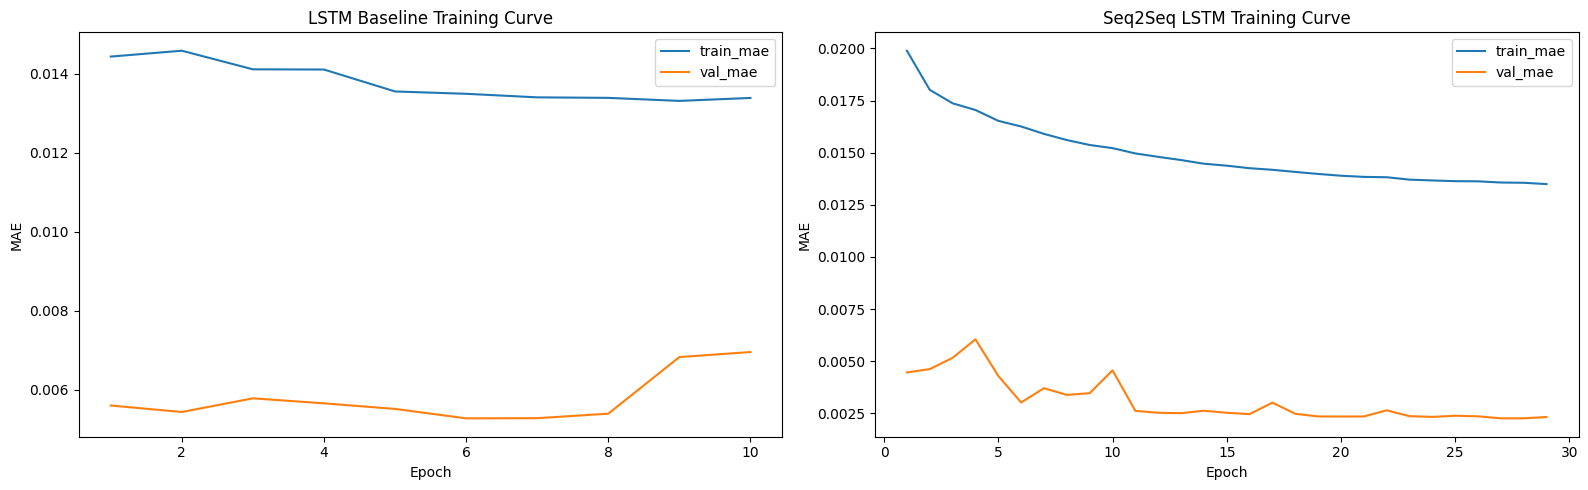

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(baseline_history_custom_df['epoch'], baseline_history_custom_df['mae'], label='train_mae')
axes[0].plot(baseline_history_custom_df['epoch'], baseline_history_custom_df['val_mae'], label='val_mae')
axes[0].set_title('LSTM Baseline Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE')
axes[0].legend()

axes[1].plot(seq2seq_history_custom_df['epoch'], seq2seq_history_custom_df['mae'], label='train_mae')
axes[1].plot(seq2seq_history_custom_df['epoch'], seq2seq_history_custom_df['val_mae'], label='val_mae')
axes[1].set_title('Seq2Seq LSTM Training Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
plt.tight_layout()
plt.show()

In [66]:
baseline_test_predictions = predict_baseline_direct(
    baseline_LSTM_model, 
    X_test
)

seq2seq_test_predictions = predict_seq2seq_autoregressive(
    seq2seq_LSTM_model,
    X_test,
    test_last_close,
    horizon=HORIZON,
    batch_size=BATCH_SIZE,
)

baseline_custom_mae, baseline_custom_comparison_df = evaluate_mae_table(
    'Baseline LSTM Model with Attention',
    y_test,
    baseline_test_predictions,
)

seq2seq_custom_mae, seq2seq_custom_comparison_df = evaluate_mae_table(
    'Seq2Seq LSTM Model (Autoregressive)',
    y_test,
    seq2seq_test_predictions,
)

,jam_ke,data_aktual,hasil_prediksi,selisih
0,1,4915.090332,4547.817871,-367.272461
1,2,4856.360352,4670.667480,-185.692871
2,3,4898.660156,4651.637207,-247.022949
3,4,4932.589844,4877.826172,-54.763672
4,5,4908.710449,4863.518555,-45.191895
5,6,4914.890137,5054.470215,139.580078
6,7,4892.050293,4876.196777,-15.853516
7,8,4943.799805,4903.353516,-40.446289
8,9,4976.910156,4759.011719,-217.898438
9,10,4936.270020,4474.415039,-461.854980


,jam_ke,data_aktual,hasil_prediksi,selisih
0,1,4915.090332,5241.727051,326.636719
1,2,4856.360352,5193.970703,337.610352
2,3,4898.660156,5186.382812,287.722656
3,4,4932.589844,5193.488281,260.898438
4,5,4908.710449,5206.419434,297.708984
5,6,4914.890137,5221.737793,306.847656
6,7,4892.050293,5237.877441,345.827148
7,8,4943.799805,5254.073242,310.273438
8,9,4976.910156,5270.109863,293.199707
9,10,4936.270020,5285.974609,349.704590


# Comparison MAE Baseline LSTM vs Seq2Seq LSTM

In [ ]:
comparison_summary_df = pd.DataFrame({
    'model': ['baseline_LSTM_model', 'seq2seq_LSTM_model'],
    'test_mae_scaled': [baseline_custom_mae, seq2seq_custom_mae],
})
display(comparison_summary_df.sort_values('test_mae_scaled'))

,model,test_mae_scaled
0,baseline_LSTM_model,0.014573
1,seq2seq_LSTM_model,0.014633


In [68]:
baseline_LSTM_model.save('model_baseline_LSTM.keras')
seq2seq_LSTM_model.save('model_seq2seq_LSTM.keras')

## Line chart baseline LSTM

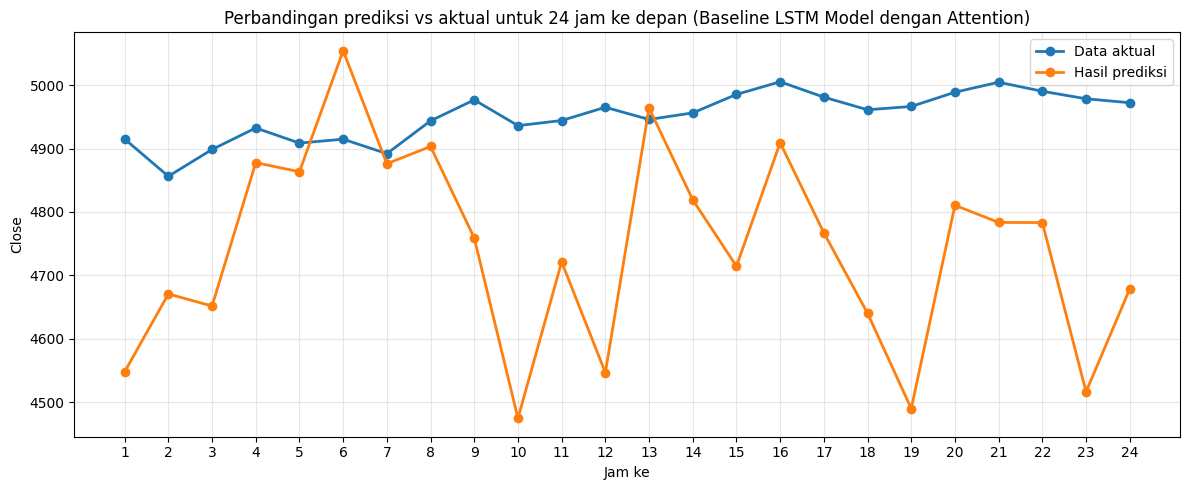

In [69]:
plt.figure(figsize=(12, 5))
plt.plot(
    baseline_custom_comparison_df['jam_ke'],
    baseline_custom_comparison_df['data_aktual'],
    marker='o',
    linewidth=2,
    label='Data aktual',
)
plt.plot(
    baseline_custom_comparison_df['jam_ke'],
    baseline_custom_comparison_df['hasil_prediksi'],
    marker='o',
    linewidth=2,
    label='Hasil prediksi',
)
plt.title('Perbandingan prediksi vs aktual untuk 24 jam ke depan (Baseline LSTM Model dengan Attention)')
plt.xlabel('Jam ke')
plt.ylabel('Close')
plt.xticks(baseline_custom_comparison_df['jam_ke'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Line chart Seq2Seq LSTM

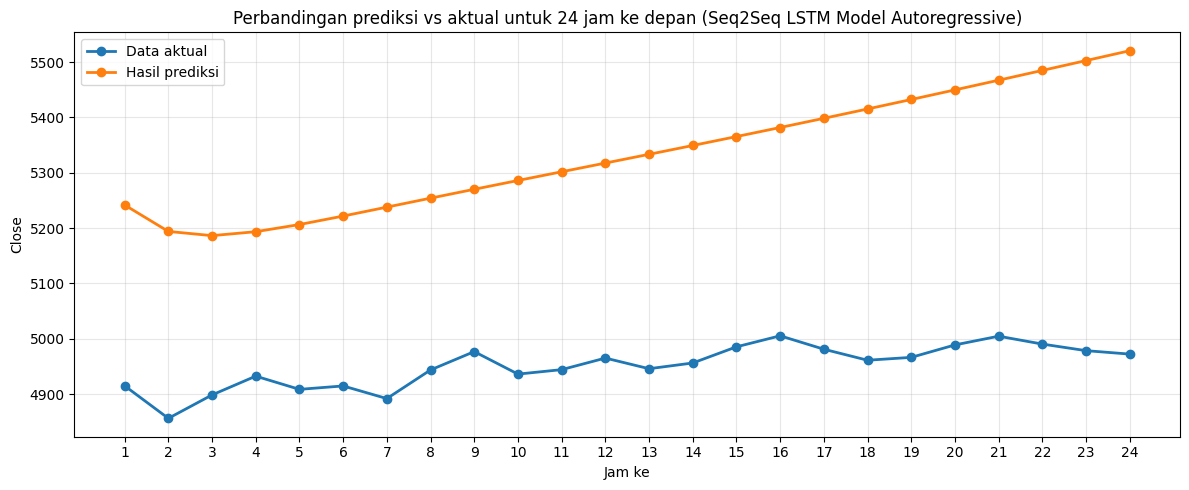

In [70]:
plt.figure(figsize=(12, 5))
plt.plot(
    seq2seq_custom_comparison_df['jam_ke'],
    seq2seq_custom_comparison_df['data_aktual'],
    marker='o',
    linewidth=2,
    label='Data aktual',
)
plt.plot(
    seq2seq_custom_comparison_df['jam_ke'],
    seq2seq_custom_comparison_df['hasil_prediksi'],
    marker='o',
    linewidth=2,
    label='Hasil prediksi',
)
plt.title('Perbandingan prediksi vs aktual untuk 24 jam ke depan (Seq2Seq LSTM Model Autoregressive)')
plt.xlabel('Jam ke')
plt.ylabel('Close')
plt.xticks(seq2seq_custom_comparison_df['jam_ke'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [71]:
seq2seq_LSTM_model.save('best_model_seq2seq_LSTM.keras')